In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/test_dataset.csv", parse_dates=["date"])
df = df.sort_values(["participant", "date"]).reset_index(drop=True)

# z-score par participant
def z(col):
    return df.groupby("participant")[col].transform(lambda s: (s - s.mean()) / s.std())

df["wellness"] = df[["fatigue", "mood", "sleep_quality", "soreness", "stress"]].mean(axis=1)

comp = pd.DataFrame({
    "wellness": z("wellness"),
    "sommeil": z("overall_score"),
    "rhr": -z("rhr"),   # rhr plus haute que d'habitude = moins bien
})

# moyenne des composantes dispo, 50 = jour normal
df["indice"] = (50 + 15 * comp.mean(axis=1)).clip(0, 100)
df.loc[comp.notna().sum(axis=1) < 2, "indice"] = np.nan

df.groupby("participant")["indice"].describe()

,count,mean,std,min,25%,50%,75%,max
participant,,,,,,,,
p01,150.0,49.850528,10.074110,17.323178,43.487065,50.680479,57.577992,70.958993
p03,86.0,49.807724,10.995665,16.128653,43.640690,52.319587,57.361011,70.356313
p05,125.0,49.444313,10.701517,26.103177,42.731889,50.190021,56.199059,73.949920


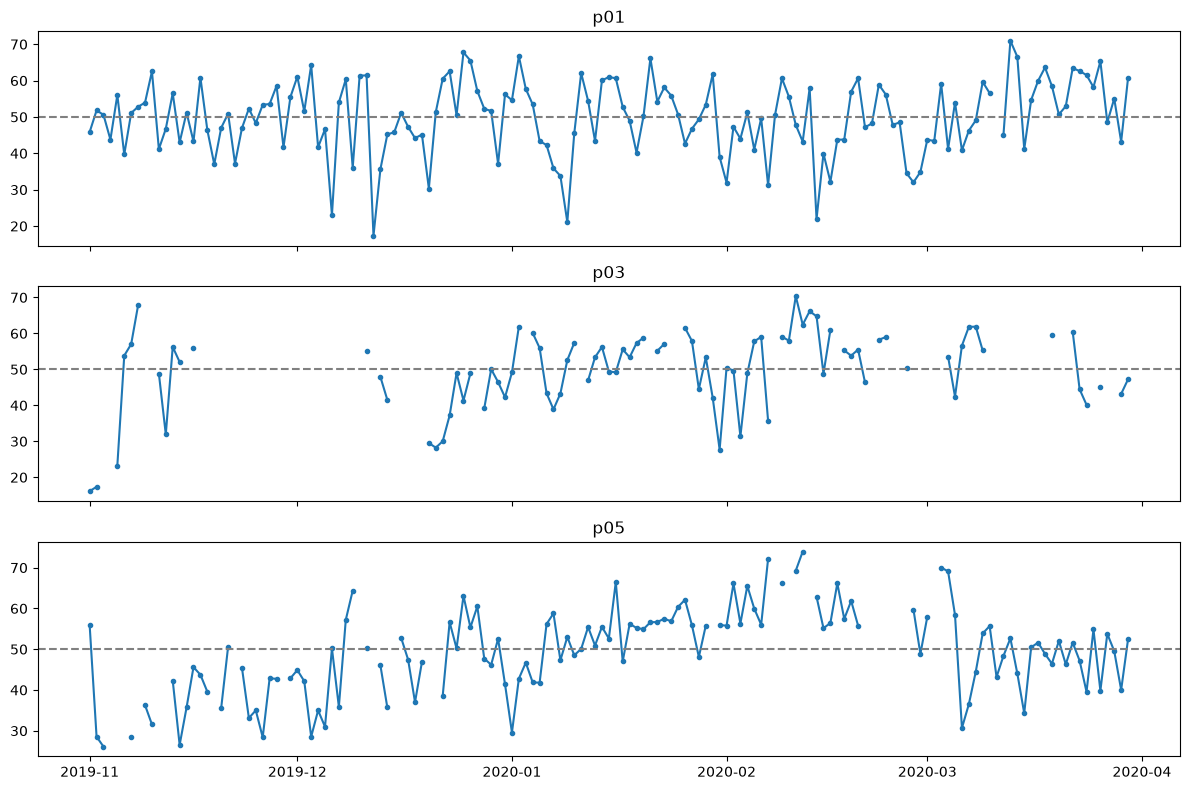

In [2]:
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for a, (p, d) in zip(ax, df.groupby("participant")):
    a.plot(d["date"], d["indice"], marker=".", linestyle="-")
    a.axhline(50, color="grey", linestyle="--")
    a.set_title(p)
plt.tight_layout()
plt.show()

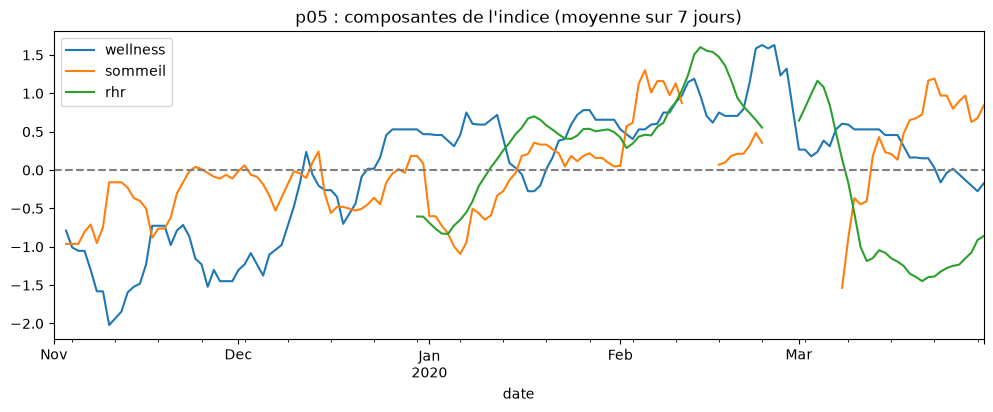

In [3]:
p5 = df["participant"] == "p05"
comp[p5].set_index(df.loc[p5, "date"]).rolling(7, min_periods=3).mean().plot(figsize=(12, 4))
plt.axhline(0, color="grey", linestyle="--")
plt.title("p05 : composantes de l'indice (moyenne sur 7 jours)")
plt.show()

In [4]:
# hausse de p05 en janvier-février pas seulement due au questionnaire, la rhr baisse aussi et le sommeil s'améliore -> probablement réelle
# mais en nov-déc pas de rhr pour p05 donc indice basé surtout sur le questionnaire -> à prendre avec prudence
# début mars rhr et sommeil chutent alors que le questionnaire bouge pas -> la montre voit la maladie, pas le questionnaire
# -> intérêt de combiner subjectif et objectif

In [5]:
g = df.groupby("participant")

def roll(col, n):
    return g[col].transform(lambda s: s.rolling(n, min_periods=n // 2).mean())

# charge sur 7 et 28 jours
df["charge_7j"] = roll("train_load", 7)
df["charge_28j"] = roll("train_load", 28)
df["acwr"] = df["charge_7j"] / df["charge_28j"].replace(0, np.nan)

# moyennes récentes
df["pas_7j"] = roll("steps", 7)
df["sommeil_3j"] = roll("sleep_minutes", 3)
df["score_sommeil_3j"] = roll("overall_score", 3)
df["wellness_3j"] = roll("wellness", 3)

# rhr comparée aux 7 jours d'avant
rhr_avant = g["rhr"].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
df["rhr_ecart"] = df["rhr"] - rhr_avant

In [6]:
df["indice_demain"] = g["indice"].shift(-1)

In [7]:
inj = df["injured"].fillna(0)
deja = inj.groupby(df["participant"]).transform(lambda s: s.shift(1).rolling(21, min_periods=1).max())
df["debut_blessure"] = ((inj == 1) & (deja != 1)).astype(int)

# 1 si un début de blessure arrive entre J+1 et J+7
df["blessure_7j"] = g["debut_blessure"].transform(
    lambda s: s[::-1].rolling(7, min_periods=1).max()[::-1].shift(-1)
)

print(df.loc[df["debut_blessure"] == 1, ["participant", "date"]])
print(df["blessure_7j"].value_counts())

    participant       date
67          p01 2020-01-07
304         p05 2019-11-01
394         p05 2020-01-30
blessure_7j
0.0    439
1.0     14
Name: count, dtype: int64


In [8]:
# 3 débuts de blessure : p01 le 07/01, p05 le 01/11 et le 30/01
# 14 jours positifs sur 453 (~3%), en vrai que 2 épisodes utilisables (le 01/11 est le 1er jour de l'étude)
# -> modèle blessure forcément très fragile

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

feats = ["indice", "wellness", "overall_score", "rhr_ecart", "wellness_3j",
         "score_sommeil_3j", "sommeil_3j", "pas_7j", "charge_7j", "acwr"]

data = df.dropna(subset=["indice_demain"]).sort_values("date")
coupure = pd.Timestamp("2020-02-15")
train = data[data["date"] < coupure]
test = data[data["date"] >= coupure]
print(len(train), "jours train,", len(test), "jours test")

y_test = test["indice_demain"]
print("toujours 50 :", round(mean_absolute_error(y_test, [50] * len(y_test)), 1))
print("comme aujourd'hui :", round(mean_absolute_error(y_test, test["indice"].fillna(50)), 1))

258 jours train, 100 jours test
toujours 50 : 7.6
comme aujourd'hui : 8.0


In [10]:
cv = TimeSeriesSplit(n_splits=4)

ridge = GridSearchCV(
    make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge()),
    {"ridge__alpha": [0.1, 1, 10, 100]},
    cv=cv, scoring="neg_mean_absolute_error")

rf = GridSearchCV(
    make_pipeline(SimpleImputer(strategy="median"), RandomForestRegressor(n_estimators=300, random_state=42)),
    {"randomforestregressor__max_depth": [2, 4, 6],
     "randomforestregressor__min_samples_leaf": [5, 10, 20]},
    cv=cv, scoring="neg_mean_absolute_error")

for nom, m in [("ridge", ridge), ("rf", rf)]:
    m.fit(train[feats], train["indice_demain"])
    pred = m.predict(test[feats])
    print(nom, m.best_params_, "MAE test :", round(mean_absolute_error(y_test, pred), 1))

ridge {'ridge__alpha': 10} MAE test : 7.2
rf {'randomforestregressor__max_depth': 6, 'randomforestregressor__min_samples_leaf': 10} MAE test : 7.7


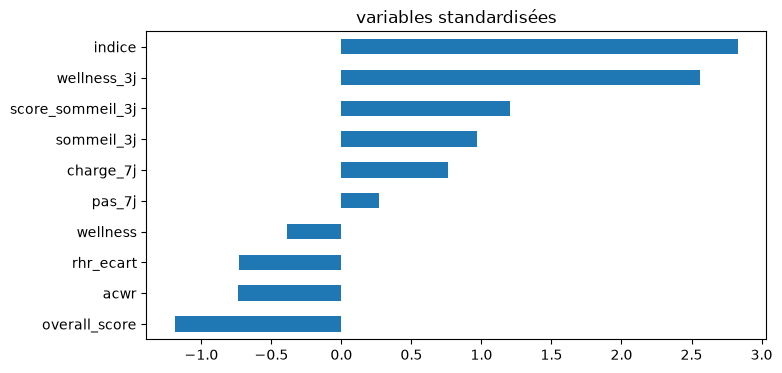

In [11]:
best = ridge.best_estimator_
coefs = pd.Series(best.named_steps["ridge"].coef_, index=feats).sort_values()
coefs.plot.barh(figsize=(8, 4))
plt.title("variables standardisées")
plt.show()

In [12]:
# variables les plus utilisées : indice du jour, wellness_3j, sommeil sur 3j
# rhr_ecart et acwr négatifs -> rhr plus haute ou hausse brutale de charge = moins bien le lendemain
# overall_score négatif mais score_sommeil_3j positif : variables trop corrélées (multicolinéarité), on lit l'effet combiné, pas les signes un par un

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

feats_b = ["charge_7j", "charge_28j", "acwr", "pas_7j", "sommeil_3j",
           "score_sommeil_3j", "wellness_3j", "rhr_ecart"]
data_b = df.dropna(subset=["blessure_7j"])

modele = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                       LogisticRegression(class_weight="balanced", C=0.1, max_iter=1000))

for p in ["p01", "p05"]:
    tr = data_b[data_b["participant"] != p]
    te = data_b[data_b["participant"] == p]
    modele.fit(tr[feats_b], tr["blessure_7j"])
    proba = modele.predict_proba(te[feats_b])[:, 1]
    print(p, "AUC ROC :", round(roc_auc_score(te["blessure_7j"], proba), 2),
          "PR-AUC :", round(average_precision_score(te["blessure_7j"], proba), 2),
          "hasard :", round(te["blessure_7j"].mean(), 2))

p01 AUC ROC : 0.1 PR-AUC : 0.03 hasard : 0.05
p05 AUC ROC : 0.41 PR-AUC : 0.04 hasard : 0.05


In [14]:
# p01 AUC 0.10 , p05 AUC 0.41 -> en dessous du hasard (0.5), le modèle prédit rien
# 1 seul épisode dans chaque entrainement, et 2 blessures très différentes (main vs pied)
# -> pas assez de blessures pour apprendre, on force pas le modèle sinon ça marcherait juste par chance

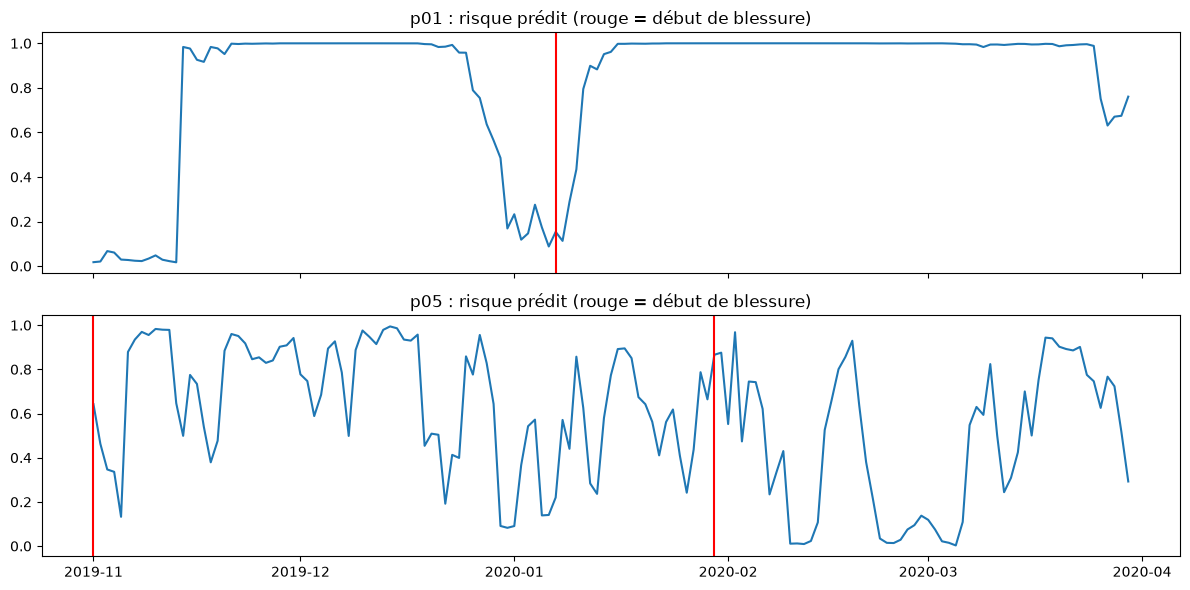

In [15]:
morceaux = []
for p in ["p01", "p05"]:
    tr = data_b[data_b["participant"] != p]
    te = data_b[data_b["participant"] == p].copy()
    modele.fit(tr[feats_b], tr["blessure_7j"])
    te["risque"] = modele.predict_proba(te[feats_b])[:, 1]
    morceaux.append(te)
risque = pd.concat(morceaux)

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for a, (p, d) in zip(ax, risque.groupby("participant")):
    a.plot(d["date"], d["risque"])
    for jour in d.loc[d["debut_blessure"] == 1, "date"]:
        a.axvline(jour, color="red")
    a.set_title(p + " : risque prédit (rouge = début de blessure)")
plt.tight_layout()
plt.show()

In [16]:
# le modèle compare p01 aux autres (p01 s'entraine beaucoup plus) -> risque à 1 tout le temps
# on compare chaque participant à sa propre habitude, comme pour l'indice

In [17]:
# variables comparées à l'habitude de chaque participant
feats_z = []
for c in feats_b:
    df[c + "_z"] = df.groupby("participant")[c].transform(lambda s: (s - s.mean()) / s.std())
    feats_z.append(c + "_z")

data_b = df.dropna(subset=["blessure_7j"])

for p in ["p01", "p05"]:
    tr = data_b[data_b["participant"] != p]
    te = data_b[data_b["participant"] == p]
    modele.fit(tr[feats_z], tr["blessure_7j"])
    proba = modele.predict_proba(te[feats_z])[:, 1]
    print(p, "AUC ROC :", round(roc_auc_score(te["blessure_7j"], proba), 2),
          "PR-AUC :", round(average_precision_score(te["blessure_7j"], proba), 2))

p01 AUC ROC : 0.09 PR-AUC : 0.03
p05 AUC ROC : 0.12 PR-AUC : 0.03


In [18]:
# avec les variables comparées à l'habitude : p01 0.09 , p05 0.12 -> toujours en dessous du hasard
# ce que le modèle apprend sur une blessure est l'inverse de l'autre -> pas de profil commun entre les 2 épisodes
# on retourne pas les prédictions (ce serait tricher), avec 2 blessures différentes y a rien de général à apprendre

In [19]:
def zp(col):
    return df.groupby("participant")[col].transform(lambda s: (s - s.mean()) / s.std())

alerte = pd.DataFrame({
    "charge": df["acwr"] > 1.5,             # hausse brutale de charge
    "rhr": zp("rhr_ecart") > 1,             # rhr bien plus haute que d'habitude
    "sommeil": zp("sommeil_3j") < -1,       # sommeil bien plus court que d'habitude
    "wellness": zp("wellness_3j") < -1,     # bien-être bien plus bas que d'habitude
})
df["risque_regles"] = alerte.sum(axis=1)

# risque moyen avant une blessure vs les autres jours
print(df.groupby("blessure_7j")["risque_regles"].mean())

blessure_7j
0.0    0.528474
1.0    0.428571
Name: risque_regles, dtype: float64


In [20]:
# score par règles : 0.43 avant une blessure vs 0.53 les autres jours -> fait pas mieux
# 3 approches (logistique, logistique avec habitude, règles) -> même conclusion
# les 2 blessures sont pas précédées des signes classiques (charge, rhr, sommeil, wellness)
# la main de p01 ressemble plus à un accident qu'à une blessure de surcharge -> pas prévisible avec ces données
# pour aller plus loin : plus de participants, distinguer blessures traumatiques et de surcharge